In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
from collections import deque
import random
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, terminated):
        self.buffer.append((state, action, reward, next_state, terminated))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, terminated = zip(*transitions)
        return np.array(states), actions, rewards, np.array(next_states), terminated

    def size(self):
        return len(self.buffer)

In [3]:
class Qnet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
class DQN:
    def __init__(self, state_dim, hidden_dim, action_dim, eps, device, gamma, lr, target_update, mode='DQN'):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim, hidden_dim, action_dim).to(device)
        self.target_q_net = Qnet(state_dim, hidden_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

        self.eps = eps
        self.device = device
        self.gamma = gamma
        self.target_update = target_update
        self.step = 0
        self.mode = mode

    def take_action(self, state):
        if np.random.random() < self.eps:
            action = np.random.randint(0, self.action_dim)
        else:
            state = torch.tensor(state, dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def max_q_value(self, state):
        state = torch.tensor(state, dtype=torch.float).to(device)
        return self.q_net(state).max().item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        terminated = torch.tensor(transition_dict['terminated'], dtype=torch.float).view(-1, 1).to(self.device)

        q_values = torch.gather(self.q_net(states), 1, actions)
        with torch.no_grad(): # For performance
            if self.mode == 'Double DQN':
                max_actions = self.q_net(next_states).argmax(1).view(-1, 1)
                max_next_q_values = self.target_q_net(next_states).gather(1, max_actions)
            else:
                max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)  # Vanilla DQN
        target_q_values = rewards + self.gamma * max_next_q_values * (1 - terminated)
        loss = F.mse_loss(q_values, target_q_values, reduction='mean')

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.step % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.step += 1

In [5]:
num_episodes = 500
eps = 0.01
gamma = 0.98
lr = 2e-3
hidden_dim = 128
target_update = 10
buffer_size = 50000
minimal_size = 500
batch_size = 64
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

env_name = "Pendulum-v1"
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
hidden_dim = 128
# The pendulum environment has a continuous action space, but DQN and its variants can only deal with discrete action space. So we discretize the action space into 11 different values
action_dim = 11

def dis_to_con(discrete_action, env, action_dim):
    action_lowbound = env.action_space.low[0]
    action_upbound = env.action_space.high[0]
    return action_lowbound + discrete_action * (action_upbound - action_lowbound) / (action_dim - 1)

In [6]:
def train_dqn(agent, env, replay_buffer):
    return_list = []
    max_q_value_list = []
    max_q_value = 0

    for i in range(10):
        with tqdm(total=num_episodes // 10, desc="Iteration %d" % i) as pbar:
            for i_episode in range(num_episodes // 10):
                state, info = env.reset()
                episode_return = 0
                while True:
                    action = agent.take_action(state)
                    max_q_value = agent.max_q_value(state) * 0.005 + max_q_value * 0.995
                    max_q_value_list.append(max_q_value)
                    action_continuous = dis_to_con(action, env, action_dim)
                    next_state, reward, terminated, truncated, info = env.step([action_continuous])
                    replay_buffer.add(state, action, reward, next_state, terminated)
                    episode_return += reward
                    state = next_state

                    if replay_buffer.size() > minimal_size:
                        b_s, b_a, b_r, b_n, b_t = replay_buffer.sample(batch_size)
                        transition_dict = {
                            "states": b_s,
                            "actions": b_a,
                            "rewards": b_r,
                            "next_states": b_n,
                            "terminated": b_t
                        }
                        agent.update(transition_dict)

                    if terminated or truncated:
                        return_list.append(episode_return)
                        break

                if (i_episode + 1) % 10 == 0:
                    pbar.set_postfix({
                        'episode': '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return': '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)

    return return_list, max_q_value_list


In [7]:
def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size

    r = np.arange(1, window_size, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

Iteration 9: 100%|██████████| 50/50 [00:35<00:00,  1.40it/s, episode=500, return=-158.959]

[-1586.87408006 -1518.98943429 -1464.44462314 -1440.03412506
 -1470.13598606 -1399.98197362 -1328.36367158 -1267.77140013
 -1263.85612009 -1123.81723639 -1116.65138511 -1103.54513005
 -1029.92803565  -927.88121182  -984.14287651  -918.16476858
  -875.21717981  -846.98385825  -863.73010688  -782.57102579
  -802.62652106  -822.50308457  -740.61479732  -569.06395326
  -493.82317927  -502.72678705  -541.62860852  -729.67297238
  -805.21521211  -781.03763545  -649.74596978  -417.5483534
  -280.40995407  -384.67887318  -480.2591129   -503.93122437
  -503.95594564  -479.43521433  -348.3133437   -280.78300047
  -353.12830299  -546.63730194  -560.67043929  -613.17799157
  -607.45899439  -460.48242242  -313.83253161  -272.61380621
  -170.77211994  -199.02862049  -224.37259428  -407.21140793
  -405.68023789  -460.93886403  -409.90019948  -487.11338269
  -351.42721858  -327.35849426  -451.118989    -607.22269166
  -529.89905644  -482.51601702  -560.92748991  -479.61156218
  -377.00009112  -377.208

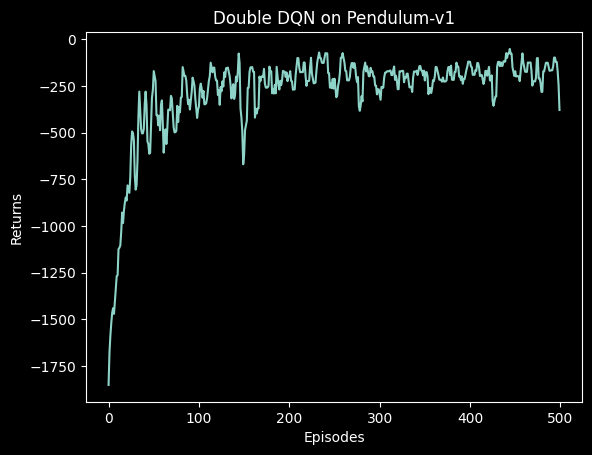

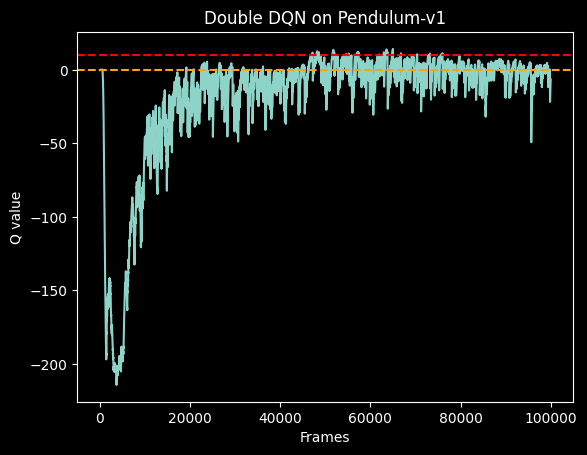

In [12]:
mode = 'Double DQN'

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
env.reset(seed=0)
agent = DQN(state_dim, hidden_dim, action_dim, eps, device, gamma, lr, target_update, mode)
replay_buffer = ReplayBuffer(buffer_size)

return_list, max_q_value_list = train_dqn(agent, env, replay_buffer)

episodes_list = list(range(len(return_list)))
mv_return = moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

Iteration 9: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s, episode=500, return=-183.625]

[-1567.40181276 -1470.42630882 -1430.0205436  -1406.62033837
 -1413.67146603 -1347.31919497 -1353.20687266 -1329.11209488
 -1378.0960909  -1326.82173629 -1303.3891582  -1236.60744824
 -1159.53557704 -1009.13589996 -1073.25257455 -1040.15762649
 -1043.1668955  -1012.51935271 -1027.00279196  -952.53452263
  -948.08973571  -951.4922022   -939.75414342  -919.15293548
  -887.33541492  -863.5507509   -822.61773819  -789.32363277
  -819.47503369  -800.64484089  -799.99452621  -747.8504879
  -716.25974667  -669.47226569  -746.14914574  -743.80595285
  -831.22689903  -857.12363021  -843.2444743   -768.33964546
  -793.39162373  -736.48073821  -792.21727656  -822.79776467
  -819.51892201  -799.38316412  -782.30819812  -751.53371097
  -674.13464228  -668.5018255   -600.38674364  -589.37535539
  -513.13465424  -520.41443841  -451.20171358  -418.17030864
  -422.87213325  -422.4661254   -443.96592442  -439.84038815
  -464.4828657   -406.63677623  -356.96404022  -301.40836398
  -330.35031868  -280.112

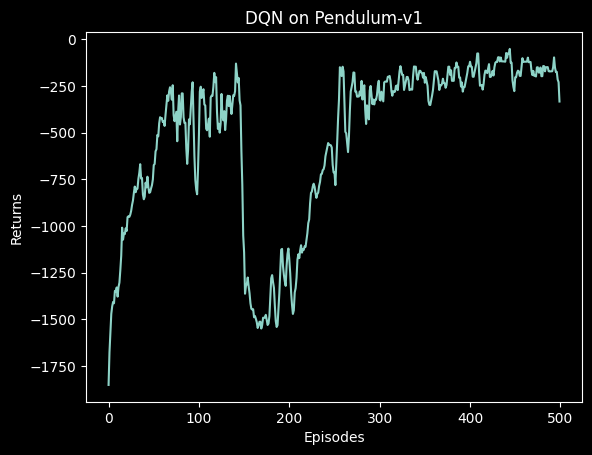

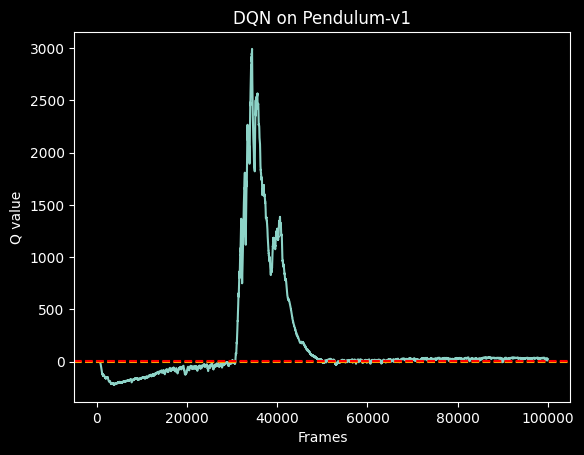

In [13]:
mode = 'DQN'

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
env.reset(seed=0)
agent = DQN(state_dim, hidden_dim, action_dim, eps, device, gamma, lr, target_update, mode)
replay_buffer = ReplayBuffer(buffer_size)

return_list, max_q_value_list = train_dqn(agent, env, replay_buffer)

episodes_list = list(range(len(return_list)))
mv_return = moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('DQN on {}'.format(env_name))
plt.show()